# Exercise: Predict Employee Salary (Multiple Linear Regression)

**Scenario:** Your company's salary negotiations currently run on vibes and one manager's gut feeling. 😵 Time to bring in some math. You're on the HR analytics team, and you want to predict an employee's **annual salary (in ₹ LPA — lakhs per annum)** from three things you actually know:

- `years_experience` — total work experience in years
- `education_level` — `1` = Bachelor's, `2` = Master's, `3` = PhD (a.k.a. "permanent Headache Degree" 😉)
- `certifications` — number of professional certifications collected

Salary clearly depends on **more than one** thing, so this is a **Multiple Linear Regression** problem:

**salary = m1·experience + m2·education + m3·certifications + b**

---
> This is the **solution** notebook — no peeking until you've sweated through `exercise_problem_statement_linear_reg.ipynb` first! 🕵️

## Step 1 — Load the data

Read `salary_data.csv` into a pandas DataFrame and look at the first few rows.

In [1]:
import pandas as pd

df = pd.read_csv("salary_data.csv")
df.head()

,years_experience,education_level,certifications,salary_lpa
0,11.8,2,5,37.8
1,7.1,3,0,22.2
2,13.0,2,2,32.0
3,10.8,2,4,32.0
4,2.3,3,2,15.5


## Step 2 — Look at your data first

Before modelling, get a feel for the numbers. `describe()` shows the range of each column, and a scatter plot shows the strongest single relationship — experience vs salary.

In [2]:
df.describe()

,years_experience,education_level,certifications,salary_lpa
count,60.000000,60.000000,60.000000,60.000000
mean,8.283333,2.000000,2.450000,24.956667
std,3.970321,0.781133,1.598993,9.092600
min,1.100000,1.000000,0.000000,5.300000
25%,4.800000,1.000000,1.000000,16.600000
50%,8.250000,2.000000,2.000000,25.300000
75%,11.825000,3.000000,4.000000,32.150000
max,14.700000,3.000000,5.000000,40.100000


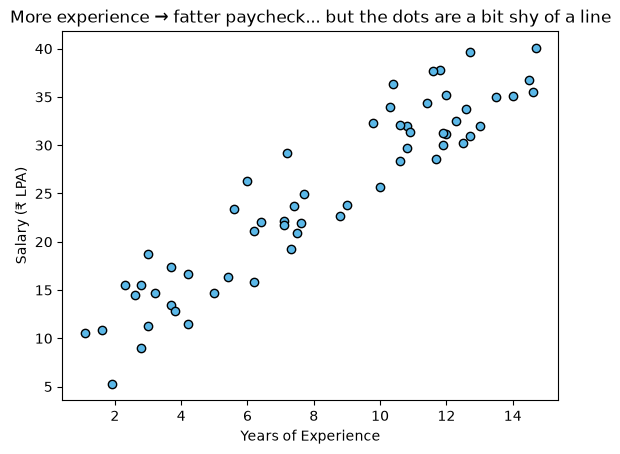

In [3]:
import matplotlib.pyplot as plt

plt.scatter(df.years_experience, df.salary_lpa, color='#5BB8E8', edgecolor='k')
plt.xlabel("Years of Experience")
plt.ylabel("Salary (₹ LPA)")
plt.title("More experience → fatter paycheck... but the dots are a bit shy of a line")
plt.show()

## Step 3 — Train the Multiple Linear Regression model

Use **all three** independent variables to predict salary.

**salary = m1·experience + m2·education + m3·certifications + b**

In [4]:
from sklearn.linear_model import LinearRegression

features = ['years_experience', 'education_level', 'certifications']
model = LinearRegression()
model.fit(df[features], df.salary_lpa)

for name, m in zip(features, model.coef_):
    print(f"{name:18s} -> {m:.2f} LPA")
print(f"{'intercept (b)':18s} -> {model.intercept_:.2f} LPA")

years_experience   -> 1.98 LPA
education_level    -> 2.57 LPA
certifications     -> 1.17 LPA
intercept (b)      -> 0.54 LPA


**Read the coefficients like a story:**
- every extra **year of experience** adds ~₹2 LPA (loyalty pays 💰)
- every step up in **education level** adds ~₹2.5 LPA (the student loans were worth it... probably 🎓)
- every extra **certification** adds ~₹1 LPA (all those weekend courses finally count)
- the **intercept** is your baseline salary before any of these kick in — the "just showed up" pay

## Step 4 — Predict for a new employee

A new candidate walks in with **5 years of experience, a Master's degree (level 2), and 3 certifications**. What salary should you offer before they start negotiating? 🤝

In [5]:
new_employee = pd.DataFrame({
    'years_experience': [5],
    'education_level': [2],
    'certifications': [3]
})
predicted = model.predict(new_employee)
print(f"Predicted salary: ₹{predicted[0]:.1f} LPA")

Predicted salary: ₹19.1 LPA


## Recap
- **Multiple Linear Regression** fits: `y = m1·x1 + m2·x2 + m3·x3 + b`
- `model.coef_` gives one slope **m** per feature; `model.intercept_` is **b**
- Read each coefficient as "how much salary changes per unit of that feature"
- Using several useful variables usually predicts better than betting on just one 🏆